In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

# evaluation imports
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_json("data/telemetry_data.jsonl", lines=True)
df.head()

,timestamp,cpu_usage,memory_usage,disk_io,network_latency,recommended_action
0,2026-02-27 10:55:00,32.5,29.7,4.1,37.3,System operating normally - no action required
1,2026-02-27 10:55:39,23.3,25.8,1.8,345.7,Restart router to resolve possible network con...
2,2026-02-27 10:55:45,93.4,28.1,200.1,13.1,Run disk cleanup to remove temporary files and...
3,2026-02-27 10:55:47,90.7,27.5,150.0,256.8,Check for background downloads causing disk an...
4,2026-02-27 10:55:59,7.0,85.2,416.0,13.6,Close unused applications to free RAM; reduce ...


In [3]:
X = df[[
    "cpu_usage",
    "memory_usage",
    "disk_io",
    "network_latency"
]]
y = df["recommended_action"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
simple_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=2,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

complex_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

In [5]:
simple_model.fit(X_train, y_train)
complex_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

In [6]:
y_pred_depth_2 = simple_model.predict(X_test)
y_pred_depth_5 = complex_model.predict(X_test)

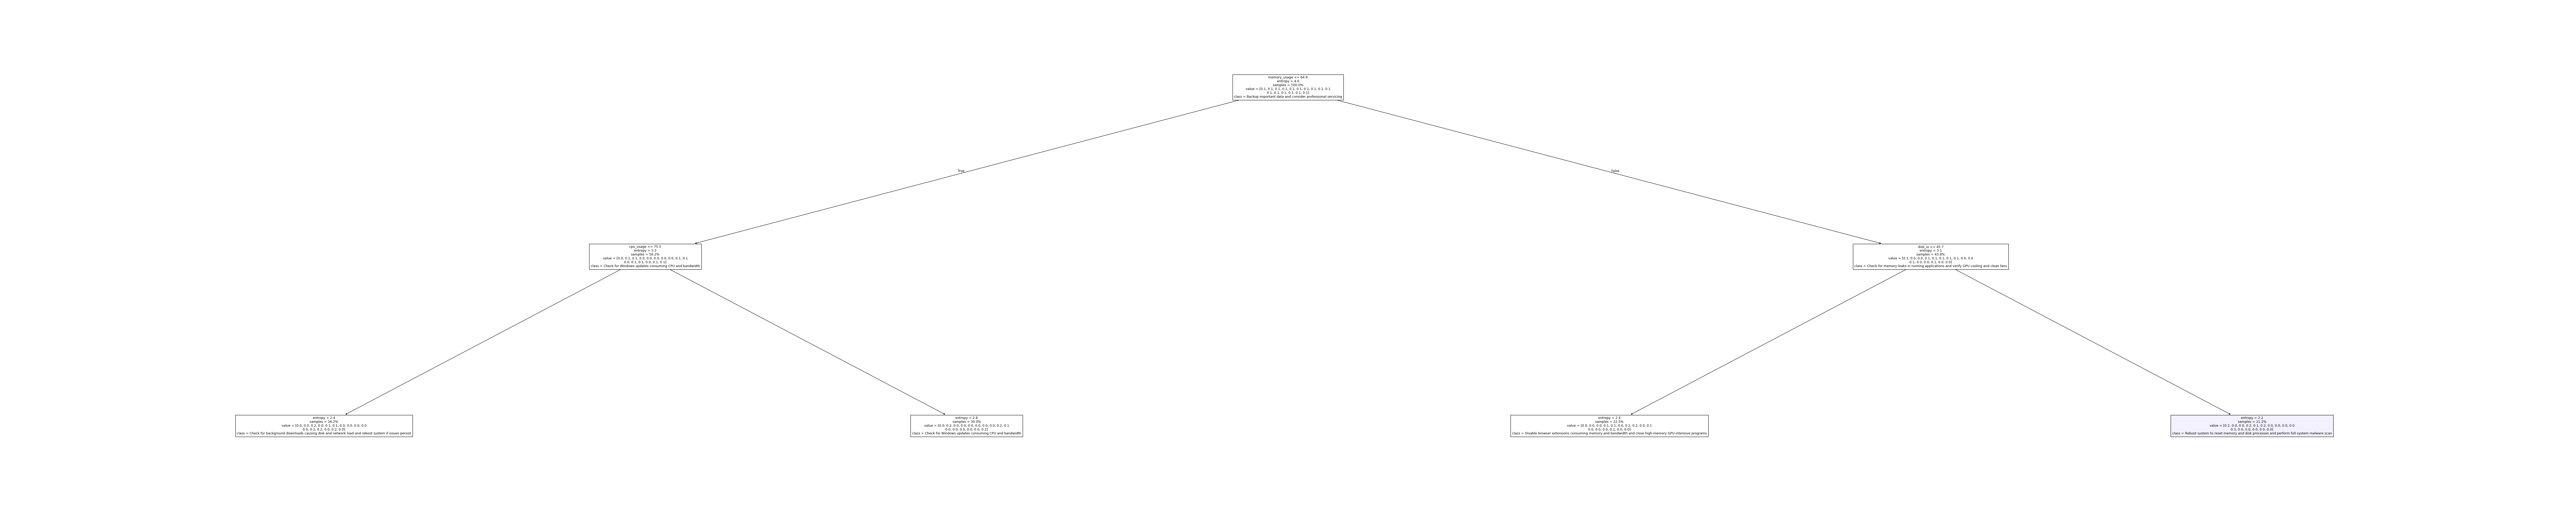

In [7]:
plt.figure(figsize=(100,20))

plot_tree(
    simple_model,
    feature_names=X.columns,
    class_names=simple_model.classes_,
    filled=True,
    proportion=True,
    fontsize=9,
    precision=1
)

plt.tight_layout()
plt.show()

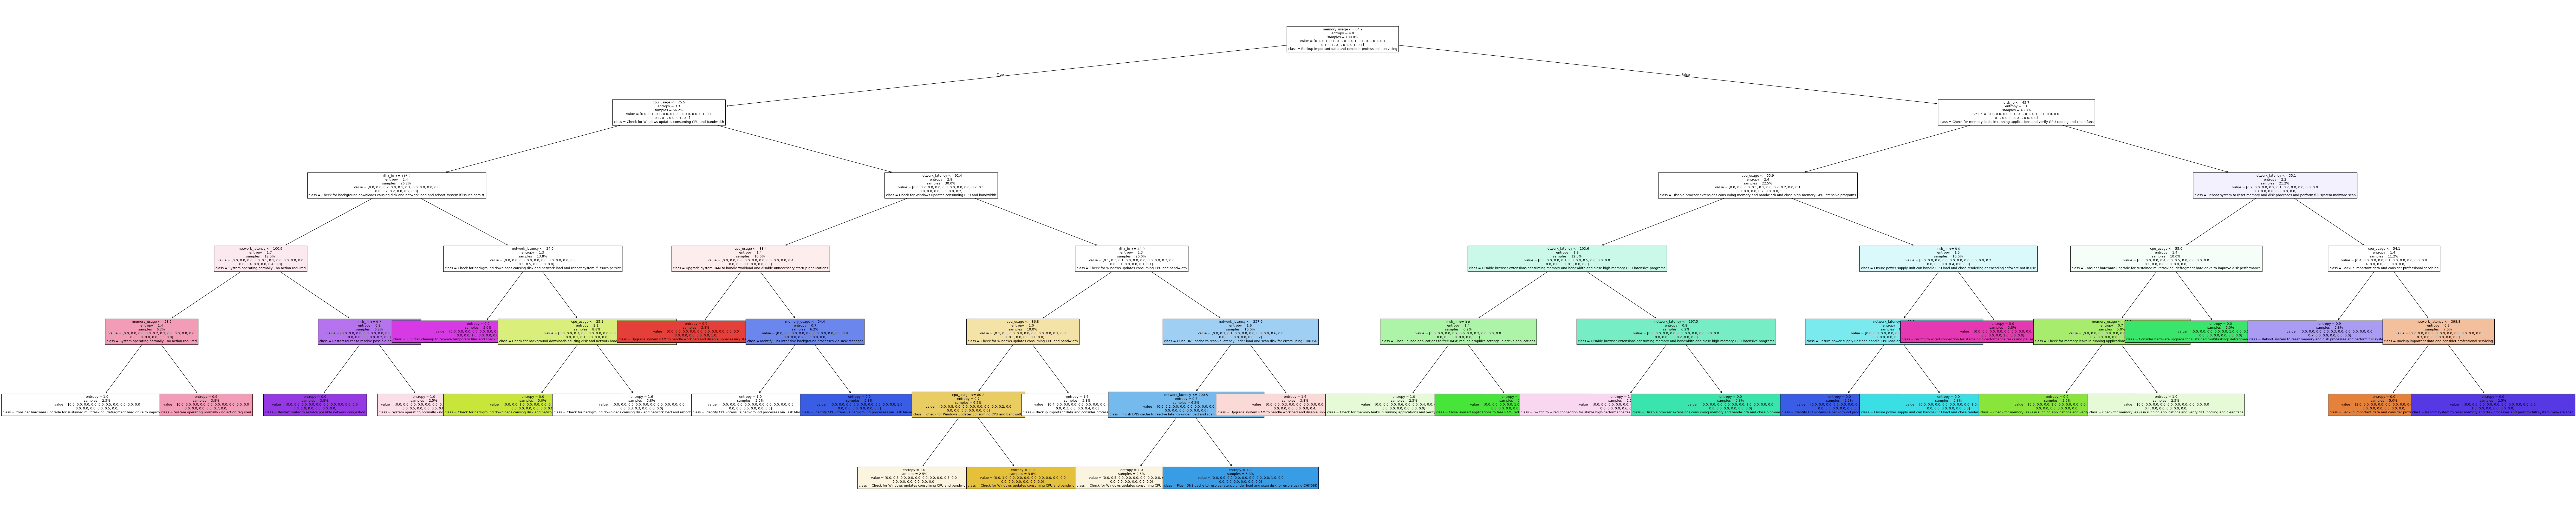

In [8]:
plt.figure(figsize=(100,20))

plot_tree(
    complex_model,
    feature_names=X.columns,
    class_names=complex_model.classes_,
    filled=True,
    proportion=True,
    fontsize=9,
    precision=1
)

plt.tight_layout()
plt.show()

In [9]:
features = ["cpu_usage", "memory_usage", "disk_io", "network_latency"]

sample_dict = {
    "cpu_usage": 32.5,
    "memory_usage": 29.7,
    "disk_io": 4.1,
    "network_latency": 37.3
}

sample = pd.DataFrame([sample_dict])

prediction_3 = simple_model.predict(sample)[0]
proba = simple_model.predict_proba(sample)[0]

tree = simple_model.tree_
feature = tree.feature
threshold = tree.threshold

node_indicator = simple_model.decision_path(sample)
leaf_id = simple_model.apply(sample)

rules = []

for node_id in node_indicator.indices:
    
    if leaf_id[0] == node_id:
        continue
        
    feature_name = features[feature[node_id]]
    
    if sample.iloc[0, feature[node_id]] <= threshold[node_id]:
        threshold_sign = "<="
    else:
        threshold_sign = ">"
        
    rules.append(
        f"{feature_name} {threshold_sign} {round(threshold[node_id],2)}"
    )

# Format output
action = prediction_3
confidence = round(np.max(proba)*100,2)

print("Recommended action:", action)
print("\nResult due to:")
for r in rules:
    print("•", r)
print("\nConfidence:", f"{confidence}%")

Recommended action: Check for background downloads causing disk and network load and reboot system if issues persist

Result due to:
• memory_usage <= 64.9
• cpu_usage <= 75.45

Confidence: 22.52%


In [ ]:
import joblib

joblib.dump(simple_model, "experiment/models/simple_model.pkl")
joblib.dump(complex_model, "experiment/models/complex_model.pkl")

print("Saved models!")

Saved models!
